<a href="https://colab.research.google.com/github/SalomeAc/Redes-Entrega1/blob/main/ENTREGA_2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ENTREGA 2**

### Entrenamiento y evaluación un modelo de detección de objetos de una sola etapa y de un modelo de detección de dos etapas


---



In [74]:
import kagglehub

path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

KAGGLE_PATH="/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


In [75]:
import os
import random
from pathlib import Path
import cv2
import numpy as np
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# **Modelo de de una etapa: Yolo**

---



##**Configuración del Dataset**

---



In [76]:

DATASET_PATH = Path(KAGGLE_PATH)
SEG_PATH     = DATASET_PATH / "Segmentation"
OUTPUT_PATH  = Path("data")

TRAIN_RATIO      = 0.70
VALIDATION_RATIO = 0.20
# TEST_RATIO     = 0.10

RANDOM_SEED = 42


TARGET_SIZE  = (320, 320)
TO_GRAYSCALE = True

CLASSES = {
    "Glioma":          0,
    "Meningioma":      1,
    "Pituitary tumor": 2,
}

random.seed(RANDOM_SEED)


print(f"Dataset original: {DATASET_PATH}")
print(f"Clases: {CLASSES}")
print(f"Tamaño objetivo: {TARGET_SIZE}")
print(f"Escala de grises: {TO_GRAYSCALE}")


Dataset original: /kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET
Clases: {'Glioma': 0, 'Meningioma': 1, 'Pituitary tumor': 2}
Tamaño objetivo: (320, 320)
Escala de grises: True


In [77]:
splits = ["train", "validation", "test"]

for split in splits:
    (OUTPUT_PATH / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_PATH / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Folder structure created:")
for split in splits:
    print(f"   data/images/{split}/   data/labels/{split}/")

Folder structure created:
   data/images/train/   data/labels/train/
   data/images/validation/   data/labels/validation/
   data/images/test/   data/labels/test/


## **Función de preprocesamiento de imágenes**


---



In [78]:
def preprocess_and_save(src: Path, dst: Path):
  """
  Preprocesa y guarda una imagen para el formato YOLO.

    Args:
        src: Ruta de la imagen original
        dst: Ruta donde guardar la imagen procesada

    Returns:
        bool: True si se procesó correctamente, False si hubo error
  """
  img = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE if TO_GRAYSCALE else cv2.IMREAD_COLOR)
  if img is None:
      print(f"Could not read: {src}")
      return False

  original_size = (img.shape[1], img.shape[0])  # (w, h)


  if original_size != TARGET_SIZE:
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

  cv2.imwrite(str(dst), img)
  return True

## **Imágenes por clase**

---



In [88]:
total_saved = {"train": 0, "validation": 0, "test": 0}
original_sizes = []
for class_name, class_id in CLASSES.items():
  class_dir = SEG_PATH / class_name

  if not class_dir.exists():
        print(f"\n Folder not found, skipping: {class_dir}")
        continue


  all_images = sorted([
        f for f in class_dir.glob("*.png")
        if "_mask" not in f.stem
    ])

  if not all_images:
      print(f"\n No images found in {class_dir}")
      continue


  sample = cv2.imread(str(all_images[0]), cv2.IMREAD_GRAYSCALE)
  if sample is not None:
        original_sizes.append((sample.shape[1], sample.shape[0]))


  random.shuffle(all_images)
  n       = len(all_images)
  n_train = int(n * TRAIN_RATIO)
  n_val   = int(n * VALIDATION_RATIO)

  split_map = (
      [("train",      img) for img in all_images[:n_train]] +
      [("validation", img) for img in all_images[n_train:n_train + n_val]] +
      [("test",       img) for img in all_images[n_train + n_val:]]
  )

  for split, src in split_map:
      dst = OUTPUT_PATH / "images" / split / src.name
      if preprocess_and_save(src, dst):
          total_saved[split] += 1

  n_test = n - n_train - n_val
  print(f"\n {class_name}  (class_id={class_id})  |  total={n}")
  print(f"     train={n_train}  val={n_val}  test={n_test}")


orig_str = str(original_sizes[0]) if original_sizes else "unknown"

print("_________")
print("  Done — images preprocessed and saved.")
print(f"   Original size  : {orig_str}  (w × h)")
print(f"   Saved size     : {TARGET_SIZE}  (w × h)")
print(f"   Grayscale      : {TO_GRAYSCALE}")
print(f"   train          : {total_saved['train']}  images")
print(f"   validation     : {total_saved['validation']}  images")
print(f"   test           : {total_saved['test']}  images")
print(f"   TOTAL          : {sum(total_saved.values())}  images")
print("______________")




 Glioma  (class_id=0)  |  total=554
     train=387  val=110  test=57

 Meningioma  (class_id=1)  |  total=708
     train=495  val=141  test=72

 Pituitary tumor  (class_id=2)  |  total=930
     train=651  val=186  test=93
_________
  Done — images preprocessed and saved.
   Original size  : (512, 512)  (w × h)
   Saved size     : (320, 320)  (w × h)
   Grayscale      : True
   train          : 1533  images
   validation     : 437  images
   test           : 222  images
   TOTAL          : 2192  images
______________


###**Extracción de Bounding Boxes a partir de Máscaras de Segmentación y Escritura de Etiquetas YOLO**

In [89]:
"""
Para cada imagen en data/images/{split}/:
  1. Encuentra la máscara correspondiente en la carpeta original de Segmentation
  2. Detecta la región del tumor mediante contornos en la máscara binaria
  3. Convierte el bounding box a formato YOLO normalizado:
        <class_id> <x_center> <y_center> <width> <height> todos 0-1
  4. Guarda el archivo .txt en data/labels/{split}/

Estructura esperada de entrada:
  data/images/{split}/imagenes_procesadas.png

Estructura de salida:
  data/labels/{split}/imagen_stem.txt

"""
DATASET_PATH = Path(KAGGLE_PATH)
SEG_PATH     = DATASET_PATH / "Segmentation"
OUTPUT_PATH  = Path("data")


CLASSES = {
    "Glioma":          0,
    "Meningioma":      1,
    "Pituitary tumor": 2,
}

MIN_CONTOUR_AREA = 50

print(f"Dataset original: {DATASET_PATH}")
print(f"Clases: {CLASSES}")
print(f"Tamaño objetivo: {TARGET_SIZE}")
print(f"Escala de grises: {TO_GRAYSCALE}")


Dataset original: /kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET
Clases: {'Glioma': 0, 'Meningioma': 1, 'Pituitary tumor': 2}
Tamaño objetivo: (320, 320)
Escala de grises: True


### **Funciones auxiliares**

---



In [90]:
def find_mask_path(image_name: str) -> Path | None:
    """
    Encuentra la máscara correspondiente a una imagen.

    Args:
        image_name: Nombre del archivo de imagen por ejemplo, 'enh_1841.png'

    Returns:
        Path: Ruta a la máscara encontrada, o None si no existe

    Ejemplo:
        image_name = 'enh_1841.png'
        Busca: Segmentation/Glioma/enh_1841_mask.png
        Retorna: Path('Segmentation/Glioma/enh_1841_mask.png')
    """
    stem = Path(image_name).stem
    mask_name = f"{stem}_mask.png"
    for class_name in CLASSES:
        candidate = SEG_PATH / class_name / mask_name
        if candidate.exists():
            return candidate

    return None

def get_class_id_from_image(image_name: str) -> int | None:
    """
    Obtiene el ID de clase verificando en qué carpeta de Segmentation
    se encuentra la imagen original.

    Args:
        image_name: Nombre del archivo de imagen

    Returns:
        int: ID de clase (0, 1, 2), o None si no se encuentra

    Ejemplo:
        image_name = 'enh_1841.png'
        Busca: Segmentation/Glioma/enh_1841.png
        Retorna: 0 (Glioma)
    """
    stem = Path(image_name).stem

    for class_name, class_id in CLASSES.items():
        candidate = SEG_PATH / class_name / f"{stem}.png"
        if candidate.exists():
            return class_id

    return None

## **Función conversión de máscara a YOLO**

---



In [91]:
def mask_to_yolo_bboxes(mask_path: Path, class_id: int) -> list[str]:
    """
    Lee una máscara binaria y devuelve una lista de cadenas con anotaciones en formato YOLO.
    Una cadena por cada contorno de tumor detectado.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    h, w = mask.shape


    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    annotations = []
    for cnt in contours:
        if cv2.contourArea(cnt) < MIN_CONTOUR_AREA:
            continue  # skip noise

        x, y, bw, bh = cv2.boundingRect(cnt)


        x  = max(0, x)
        y  = max(0, y)
        bw = min(bw, w - x)
        bh = min(bh, h - y)

        #  YOLO formato
        x_center = (x + bw / 2) / w
        y_center = (y + bh / 2) / h
        norm_w   = bw / w
        norm_h   = bh / h

        annotations.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"
        )

    return annotations

splits = ["train", "validation", "test"]

stats = {s: {"labeled": 0, "empty": 0, "no_mask": 0} for s in splits}

for split in splits:
    images_dir = OUTPUT_PATH / "images" / split
    labels_dir = OUTPUT_PATH / "labels" / split

    image_files = sorted(images_dir.glob("*.png"))

    if not image_files:
        print(f" No images found in {images_dir}, skipping.")
        continue

    for img_path in image_files:
        label_path = labels_dir / (img_path.stem + ".txt")

        # Find mask
        mask_path = find_mask_path(img_path.name)
        if mask_path is None:
            print(f"  Mask not found for: {img_path.name}")
            label_path.write_text("")          # empty label = no tumor / background
            stats[split]["no_mask"] += 1
            continue

        # class id
        class_id = get_class_id_from_image(img_path.name)
        if class_id is None:
            print(f"  Class not resolved for: {img_path.name}")
            label_path.write_text("")
            stats[split]["no_mask"] += 1
            continue

        # Extract bboxes
        annotations = mask_to_yolo_bboxes(mask_path, class_id)

        if annotations:
            label_path.write_text("\n".join(annotations) + "\n")
            stats[split]["labeled"] += 1
        else:
            label_path.write_text("")
            stats[split]["empty"] += 1
            print(f"Empty mask (no contour): {img_path.name}")

    print(f"{split:12s}  labeled={stats[split]['labeled']}  "
          f"empty={stats[split]['empty']}  no_mask={stats[split]['no_mask']}")


print("\n" + "─" * 55)
print("Label generation complete.")
total_labeled  = sum(s["labeled"]  for s in stats.values())
total_empty    = sum(s["empty"]    for s in stats.values())
total_no_mask  = sum(s["no_mask"]  for s in stats.values())
print(f"   Annotated labels  : {total_labeled}")
print(f"   Empty masks       : {total_empty}")
print(f"   Missing masks     : {total_no_mask}")
print("\nExample label format:  <class_id> <x_center> <y_center> <width> <height>")
print("Classes               :  0=Glioma  1=Meningioma  2=Pituitary tumor")

train         labeled=1997  empty=0  no_mask=0
validation    labeled=784  empty=0  no_mask=0
test          labeled=425  empty=0  no_mask=0

───────────────────────────────────────────────────────
Label generation complete.
   Annotated labels  : 3206
   Empty masks       : 0
   Missing masks     : 0

Example label format:  <class_id> <x_center> <y_center> <width> <height>
Classes               :  0=Glioma  1=Meningioma  2=Pituitary tumor


##  **Visualización de muestras**

---



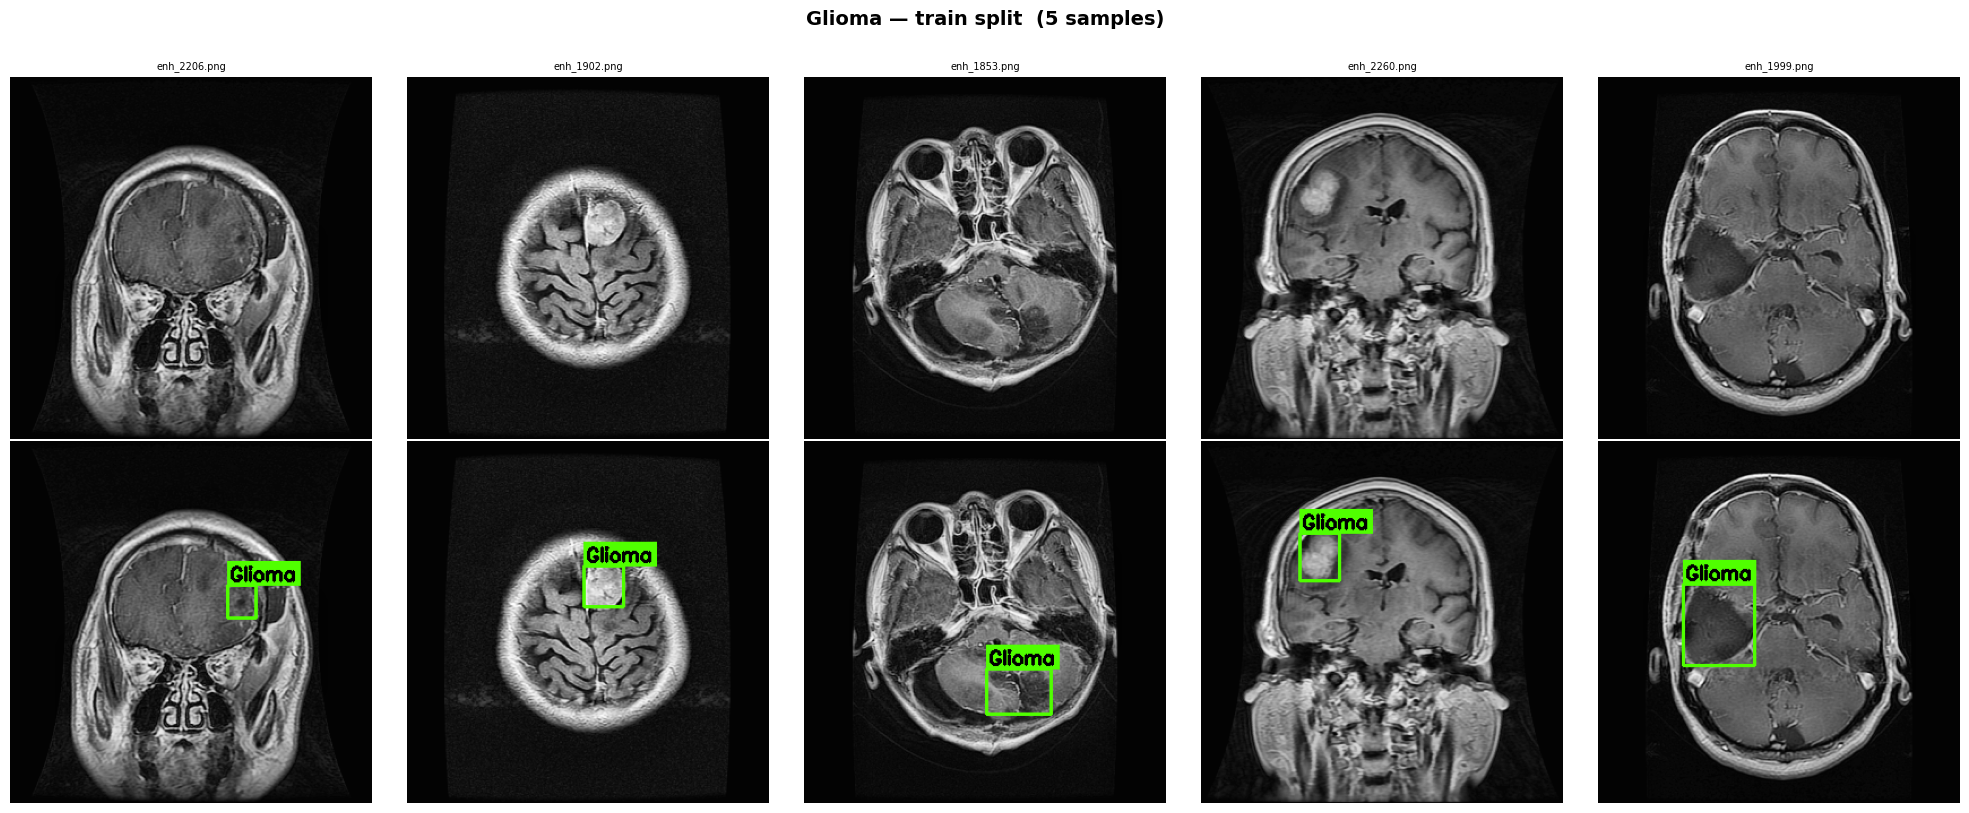

Saved: glioma_bbox_preview.png  (5 images)


In [92]:
"""
Se visualiza las imágenes del dataset con sus bounding boxes en formato YOLO.
Se Muestra la imagen original y la imagen con las anotaciones superpuestas.

Layout:
  Fila 1: Imagen original
  Fila 2: Imagen con bounding boxes YOLO
"""
DATA_PATH = Path("data")

CLASS_NAMES = {
    0: "Glioma",
    1: "Meningioma",
    2: "Pituitary Tumor"
}

CLASS_COLORS = {
    0: (0, 255, 80),     # Verde para Glioma
    1: (255, 180, 0),    # Naranja para Meningioma
    2: (0, 180, 255)     # Azul para Pituitary
}

SPLIT       = "train"
N_IMAGES    = 5
RANDOM_SEED = 42


def yolo_to_pixel(xc, yc, nw, nh, img_w, img_h):
    """Convierte coordenadas YOLO normalizadas a pixeles"""
    bw, bh = nw * img_w, nh * img_h
    cx, cy = xc * img_w, yc * img_h
    return int(cx - bw/2), int(cy - bh/2), int(cx + bw/2), int(cy + bh/2)


def load_label(label_path: Path):
    """ Carga y parsea un archivo .txt a una lista de tuplas (class_id, xc, yc, w, h)."""
    if not label_path.exists() or label_path.stat().st_size == 0:
        return []
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            boxes.append((int(parts[0]), float(parts[1]), float(parts[2]),
                          float(parts[3]), float(parts[4])))
    return boxes


def draw_boxes(img_bgr, boxes):
    """Dibuja bounding boxes YOLO sobre la imagen.n."""
    out = img_bgr.copy()
    h, w = out.shape[:2]
    for (cls, xc, yc, nw, nh) in boxes:
        x1, y1, x2, y2 = yolo_to_pixel(xc, yc, nw, nh, w, h)
        color = CLASS_COLORS.get(cls, (255, 255, 255))
        label = CLASS_NAMES.get(cls, f"class_{cls}")
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(out, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(out, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
        return out


images_dir = DATA_PATH / "images" / SPLIT
labels_dir = DATA_PATH / "labels" / SPLIT

glioma_images = []
for img_path in sorted(images_dir.glob("*.png")):
    label_path = labels_dir / (img_path.stem + ".txt")
    boxes = load_label(label_path)
    if any(cls == 0 for cls, *_ in boxes):
        glioma_images.append(img_path)

if not glioma_images:
    print("No Glioma images with labels found in", images_dir)
    exit()

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

n = min(N_IMAGES, len(glioma_images))
selected = random.sample(glioma_images, n)

# Figura con 2 filas (original | bbox) y N columnas
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle(f"Glioma — {SPLIT} split  ({n} samples)", fontsize=14, fontweight="bold", y=1.01)

for col, img_path in enumerate(selected):
    label_path = labels_dir / (img_path.stem + ".txt")
    boxes      = load_label(label_path)

    img_bgr  = cv2.imread(str(img_path))
    img_draw = draw_boxes(img_bgr, boxes)

    # Row 0 Imagen original
    axes[0, col].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(img_path.name, fontsize=7)
    axes[0, col].axis("off")

    # Row 1 — Imagen con bounding boxes
    axes[1, col].imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    # coordenadas YOLO debajo de cada imagen
    coord_lines = "\n".join(
        f"xc={xc:.3f} yc={yc:.3f}\nw={w:.3f} h={h:.3f}"
        for _, xc, yc, w, h in boxes
    )
    axes[1, col].set_xlabel(coord_lines, fontsize=7, color="#222222",
                             labelpad=6, family="monospace")
    axes[1, col].axis("off")

# Etiquetas de fila
axes[0, 0].set_ylabel("Original MRI", fontsize=11, labelpad=8)
axes[1, 0].set_ylabel("YOLO BBox",    fontsize=11, labelpad=8)
for ax in axes[:, 0]:
    ax.yaxis.set_visible(True)
    ax.tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.savefig("glioma_bbox_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: glioma_bbox_preview.png  ({n} images)")


#**Creación de  YOLO .yaml**

---



In [93]:
%%writefile data.yaml
# data.yaml, Configuración completa para YOLOv8

path: ./data

train: images/train
val:   images/validation
test:  images/test

# Número de clases
nc: 3
# Nombres de clases
names:
  0: Glioma
  1: Meningioma
  2: Pituitary tumor

#   yolo detect train data=data.yaml model=yolov8s.pt epochs=100 imgsz=640


Overwriting data.yaml


#**Train YOLO Model**

---



In [94]:
!pip install ultralytics

In [95]:
from ultralytics import YOLO
import torch
from datetime import datetime
import os
import shutil
import time

def train_yolo_model(epochs=50, batch_size=16, img_size=640, lr0=0.01,data_yaml_path="data.yaml",base_dir="./",model_save_dir="./"):

  device = '0' if torch.cuda.is_available() else 'cpu'

  # timestamp para identificar cada entrenamiento
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
  run_name = f'train_{timestamp}'

  # Modelo
  model = YOLO('yolov8n.pt')
  model_type = 'yolov8n'
  start = time.time()

  start = time.time()

  # Train - Entrenar el model
  results = model.train(
      data=data_yaml_path,
      epochs=epochs,
      batch=batch_size,
      imgsz=img_size,
      patience=10,
      save=True,
      device=device,
      project=os.path.join(base_dir, 'runs'),
      name=run_name,
      lr0=lr0,
      lrf=0.01,
      plots=True,
      save_period=5
    )

  end = time.time()
  yolo_training_time = end - start

  print(f"Training time: {yolo_training_time:.2f} s")

  model_save_path = os.path.join(model_save_dir, f"{model_type}_{timestamp}.pt")

  try:
        model.save(model_save_path)
  except Exception as e:
        print(f"Warning: Could not save model using model.save(): {e}")
        # Se usa fallback para copiar el mejor modelo generado durante el entrenamiento
        best_model_path = os.path.join(base_dir, 'runs', run_name, 'weights', 'best.pt')
        if os.path.exists(best_model_path):
            shutil.copy2(best_model_path, model_save_path)
            print(f"Copied best model from {best_model_path} to {model_save_path}")
        else:
            print(f"Error: Could not find best.pt at {best_model_path} to save the model.")

  return model, yolo_training_time


In [96]:
from pathlib import Path
from ultralytics import YOLO

"""
Se carga el modelo YOLO con los mejores pesos encontrador durante el entrenamiento
"""

model, yolo_training_time = train_yolo_model(
    epochs=50,
    batch_size=16,
    lr0=0.01
)

best_weights = max(
    Path("runs").rglob("best.pt"),
    key=lambda x: x.stat().st_mtime
)

print(best_weights)

yolo_model = YOLO(str(best_weights))

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_20260707_032840, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pe

In [97]:
from pathlib import Path

for p in Path("runs").rglob("best.pt"):
    print(p)

runs/detect/runs/train_20260707_005713/weights/best.pt
runs/detect/runs/train_20260707_032840/weights/best.pt


In [98]:
from pathlib import Path
from ultralytics import YOLO

# Buscar automáticamente el último best.pt generado
best_weights = max(
    Path("runs").rglob("best.pt"),
    key=lambda p: p.stat().st_mtime
)

print("Modelo encontrado:")
print(best_weights)

model = YOLO(str(best_weights))

Modelo encontrado:
runs/detect/runs/train_20260707_032840/weights/best.pt


## **Funciones de Validación y Métricas para YOLO**

###### Una vez finalizado el entrenamiento, el modelo se evalúa sobre el conjunto de prueba para obtener las métricas de desempeño que posteriormente serán comparadas con Faster R-CNN.
---



In [99]:
import torch
import numpy as np
import time
from torchvision.ops import box_iou

def calculate_yolo(model, test_loader, conf_threshold=0.25):
    """
    Calcula el Mean IoU para un modelo YOLO.
    """
    ious = []
    model.eval()

    with torch.no_grad():
        for images, targets in test_loader:
            for img_tensor, target in zip(images, targets):

                img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
                img_np = (img_np * 255).astype(np.uint8)

                # Prediccion YOLO
                results = model.predict(img_np, conf=conf_threshold, verbose=False)

                # Si no hay detecciones, continuar
                if len(results[0].boxes) == 0:
                    continue

                # Obtener boxes y ground truth
                yolo_boxes = results[0].boxes.xyxy.cpu()
                gt_boxes = target['boxes'].cpu()

                # Calcular IoU para cada predicción
                for yolo_box in yolo_boxes:
                    iou = box_iou(yolo_box.unsqueeze(0), gt_boxes)
                    if iou.numel() > 0:
                        ious.append(iou.max().item())

    # Calcular Mean IoU
    mean_iou = np.mean(ious) if ious else 0.0
    return mean_iou

def measure_inference_time(model, test_loader, n_samples=50, conf_threshold=0.25):
    """
    Mide el tiempo de inferencia promedio por imagen.
    """
    n_samples = min(n_samples, len(test_loader))
    start_time = time.time()

    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            if i >= n_samples:
                break
            for img_tensor in images:
                # Convertir tensor a numpy
                img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
                img_np = (img_np * 255).astype(np.uint8)
                # Inferencia
                _ = model.predict(img_np, conf=conf_threshold, verbose=False)

    inference_time = (time.time() - start_time) / n_samples
    return inference_time



In [100]:
def validate_model(model, training_time=None, test_loader=None, n_samples=50):

    metrics = model.val(
        data="data.yaml",
        split="test",
        project="data",
        name="test"
    )

    precision = metrics.box.mp
    recall = metrics.box.mr
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    yolo_metrics = {
        'mAP50': float(metrics.box.map50),
        'mAP50_95': float(metrics.box.map),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'training_time': float(training_time) if training_time else 0.0
    }

    if test_loader is not None:
        mean_iou = calculate_yolo(model, test_loader)
        yolo_metrics['mean_iou'] = mean_iou


    if test_loader is not None:
        inference_time = measure_inference_time(model, test_loader, n_samples)
        yolo_metrics['inference_time'] = inference_time

    return yolo_metrics, metrics

In [101]:
def yolo_results(yolo_metrics):

    # Metricas de rendimiento
    print(f"  mAP@50      : {yolo_metrics.get('mAP50', 0):.4f}")
    print(f"  mAP@50-95   : {yolo_metrics.get('mAP50_95', 0):.4f}")
    print(f"  Precision   : {yolo_metrics.get('precision', 0):.4f}")
    print(f"  Recall      : {yolo_metrics.get('recall', 0):.4f}")
    print(f"  F1-Score    : {yolo_metrics.get('f1', 0):.4f}")
    print(f"  Mean IoU    : {yolo_metrics.get('mean_iou', 0):.4f}")

    # Tiempos
    print("Tiempos:")
    print(f"  Training    : {yolo_metrics.get('training_time', 0):.2f} s")
    print(f"  Inference   : {yolo_metrics.get('inference_time', 0):.4f} s")
    print("="*50)

In [102]:
import os
import cv2
import torch
import torchvision.transforms.functional as F
from torch.utils.data import Dataset


class BrainTumorDataset(Dataset):

    def __init__(self, images_dir, labels_dir):

        self.images_dir = images_dir
        self.labels_dir = labels_dir

        self.images = sorted(
            [f for f in os.listdir(images_dir)
             if f.endswith(".png")]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.images_dir,
            image_name
        )

        label_path = os.path.join(
            self.labels_dir,
            image_name.replace(".png", ".txt")
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        boxes = []
        labels = []

        with open(label_path, "r") as f:

            for line in f.readlines():

                cls, xc, yc, bw, bh = map(float, line.split())

                xmin = (xc - bw/2) * w
                xmax = (xc + bw/2) * w

                ymin = (yc - bh/2) * h
                ymax = (yc + bh/2) * h

                boxes.append(
                    [xmin, ymin, xmax, ymax]
                )

                labels.append(
                    int(cls) + 1
                )

        boxes = torch.as_tensor(
            boxes,
            dtype=torch.float32
        )

        labels = torch.as_tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels
        }

        image = F.to_tensor(image)

        return image, target

In [103]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [104]:
from torch.utils.data import DataLoader
import json

test_dataset = BrainTumorDataset(
    "./data/images/test",
    "./data/labels/test"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

yolo_metrics, metrics = validate_model(
    model=model,
    training_time=yolo_training_time,
    test_loader=test_loader,
    n_samples=50
)


yolo_results(yolo_metrics)
with open('yolo_metrics.json', 'w') as f:
    json.dump(yolo_metrics, f, indent=4)
print("\n Metricas guardadas")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 377.3±497.3 MB/s, size: 54.1 KB)
val: Scanning /content/data/labels/test... 425 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 425/425 511.9it/s 0.8s
val: New cache created: /content/data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 3.0it/s 8.9s
                   all        425        425      0.952      0.901      0.967      0.748
                Glioma        107        107      0.948      0.858      0.958      0.749
            Meningioma        139        139      0.955      0.906      0.964      0.721
       Pituitary tumor        179        179      0.955      0.939      0.978      0.776
Speed: 3.7ms preprocess, 4.8ms inference, 0.0ms loss, 2.5ms postprocess per image
Results sav

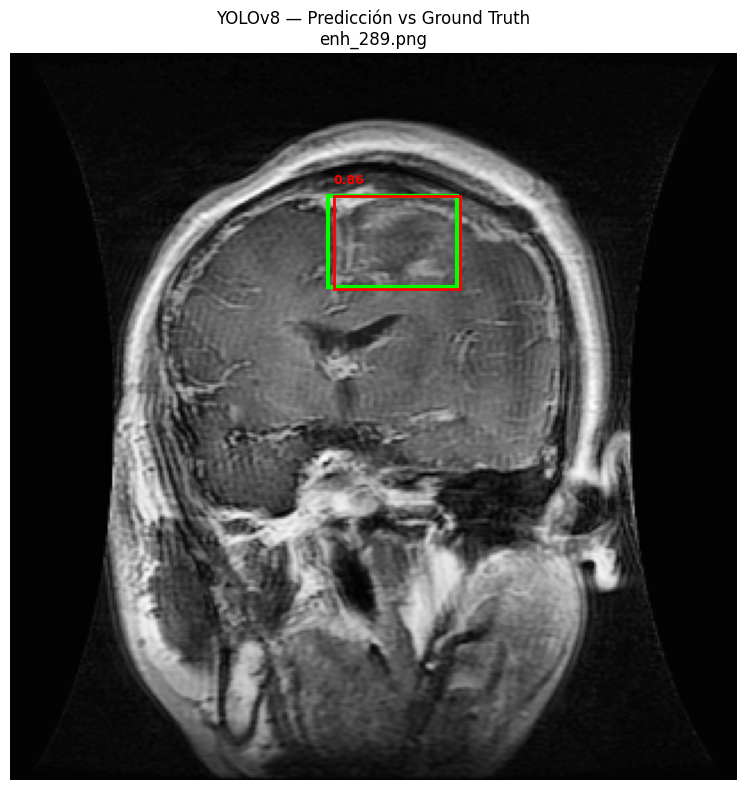

In [105]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(test_dataset) - 1)
image, target = test_dataset[idx]
img_name = test_dataset.images[idx]
img_full_path = os.path.join("./data/images/test", img_name)

yolo_pred = model.predict(img_full_path, conf=0.25, verbose=False)[0]

img_np = cv2.imread(img_full_path)
img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_np)

for box in target["boxes"]:
    xmin, ymin, xmax, ymax = box.numpy()
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                          fill=False, edgecolor="lime", linewidth=3)
    ax.add_patch(rect)

for box, score in zip(yolo_pred.boxes.xyxy.cpu(), yolo_pred.boxes.conf.cpu()):
    xmin, ymin, xmax, ymax = box.numpy()
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                          fill=False, edgecolor="red", linewidth=2)
    ax.add_patch(rect)
    ax.text(xmin, ymin - 5, f"{score:.2f}", color="red", fontsize=9, weight="bold")

ax.set_title(f"YOLOv8 — Predicción vs Ground Truth\n{img_name}")
ax.axis("off")
plt.tight_layout()
plt.savefig("yolo_prediction_sample.png", dpi=150, bbox_inches="tight")
plt.show()

In [106]:
yolo_map50 = yolo_metrics['mAP50']
yolo_map5095 = yolo_metrics['mAP50_95']
yolo_precision = yolo_metrics['precision']
yolo_recall = yolo_metrics['recall']
yolo_f1 = yolo_metrics['f1']
yolo_inference_time = yolo_metrics['inference_time']

print(f"  mAP@50      : {yolo_map50:.4f}")
print(f"  mAP@50-95   : {yolo_map5095:.4f}")
print(f"  Precision   : {yolo_precision:.4f}")
print(f"  Recall      : {yolo_recall:.4f}")
print(f"  F1-Score    : {yolo_f1:.4f}")

  mAP@50      : 0.9667
  mAP@50-95   : 0.7484
  Precision   : 0.9525
  Recall      : 0.9007
  F1-Score    : 0.9259


In [107]:
!ls

comparacion_metricas_barras.png  sample_data
comparacion_tiempos.png		 yolo26n.pt
data				 yolo_metrics.json
data.yaml			 yolo_prediction_sample.png
faster_rcnn_brain_tumor.pth	 yolov8n_20260707_005713.pt
glioma_bbox_preview.png		 yolov8n_20260707_032840.pt
runs				 yolov8n.pt


# **Modelo de dos etapas: Faster R-CNN**

In [108]:
import os
import cv2
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as F

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [109]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [110]:
class BrainTumorDataset(Dataset):

    def __init__(self, images_dir, labels_dir):

        self.images_dir = images_dir
        self.labels_dir = labels_dir

        self.images = sorted(
            [f for f in os.listdir(images_dir)
             if f.endswith(".png")]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.images_dir,
            image_name
        )

        label_path = os.path.join(
            self.labels_dir,
            image_name.replace(".png", ".txt")
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        boxes = []
        labels = []

        with open(label_path, "r") as f:

            for line in f.readlines():

                cls, xc, yc, bw, bh = map(float, line.split())

                xmin = (xc - bw/2) * w
                xmax = (xc + bw/2) * w

                ymin = (yc - bh/2) * h
                ymax = (yc + bh/2) * h

                boxes.append(
                    [xmin, ymin, xmax, ymax]
                )

                labels.append(
                    int(cls) + 1
                )

        boxes = torch.as_tensor(
            boxes,
            dtype=torch.float32
        )

        labels = torch.as_tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels
        }

        image = F.to_tensor(image)

        return image, target

In [111]:
train_dataset = BrainTumorDataset(
    "./data/images/train",
    "./data/labels/train"
)

val_dataset = BrainTumorDataset(
    "./data/images/validation",
    "./data/labels/validation"
)

test_dataset = BrainTumorDataset(
    "./data/images/test",
    "./data/labels/test"
)

In [112]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [113]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

## Carga del modelo preentrenado

---



Se utiliza Faster R-CNN con una arquitectura ResNet-50 FPN preentrenada sobre el conjunto de datos COCO. Posteriormente, la última capa de clasificación se reemplaza para adaptarla a las tres clases del problema.

In [114]:
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(
    weights=weights
)

In [115]:
num_classes = 4

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

In [116]:
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [117]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

## Entrenamiento del modelo

In [118]:
import time

start = time.time()
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    for images, targets in train_loader:

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in t.items()
            }
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

    print(
        f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}"
    )

Epoch 1/10 | Loss: 107.5828
Epoch 2/10 | Loss: 77.5121
Epoch 3/10 | Loss: 62.1107
Epoch 4/10 | Loss: 50.7603
Epoch 5/10 | Loss: 42.3710
Epoch 6/10 | Loss: 34.3518
Epoch 7/10 | Loss: 29.8038
Epoch 8/10 | Loss: 26.1373
Epoch 9/10 | Loss: 22.4672
Epoch 10/10 | Loss: 20.6047


In [119]:
faster_training_time = time.time() - start

print(f"Training time: {faster_training_time:.2f} s")

Training time: 4362.89 s


## Guardado del modelo

Una vez finalizado el entrenamiento, se almacenan los pesos del modelo para utilizarlos posteriormente durante la evaluación.

In [120]:
torch.save(
    model.state_dict(),
    "faster_rcnn_brain_tumor.pth"
)

# Evaluación del modelo Faster R-CNN

In [121]:
!pip install torchmetrics

In [122]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [123]:
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)

### **Cálculo Map**

---



In [150]:
start_time = time.time()
model.eval()
metric.reset()

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        predictions = model(images)

        preds = []
        gts = []

        for pred in predictions:
            preds.append({
                "boxes": pred["boxes"].cpu(),
                "scores": pred["scores"].cpu(),
                "labels": pred["labels"].cpu()
            })

        for target in targets:
            gts.append({
                "boxes": target["boxes"],
                "labels": target["labels"]
            })

        metric.update(preds, gts)

results = metric.compute()

n_test_images = len(test_dataset)
faster_inference_time = (time.time() - start_time) / n_test_images
print(f"Inference time (por imagen): {faster_inference_time:.4f} s")

Inference time (por imagen): 0.1015 s


In [151]:
print(f"mAP50      : {results['map_50']:.4f}")

print(f"mAP50-95   : {results['map']:.4f}")

print(f"Recall     : {results['mar_100']:.4f}")

mAP50      : 0.9236
mAP50-95   : 0.7261
Recall     : 0.7771


In [152]:
for key, value in results.items():

    print(f"{key}: {value}")

map: 0.7260627746582031
map_50: 0.9236192107200623
map_75: 0.8479783535003662
map_small: 0.6515988707542419
map_medium: 0.7547720074653625
map_large: 0.8999999761581421
mar_1: 0.7725569009780884
mar_10: 0.7771329879760742
mar_100: 0.7771329879760742
mar_small: 0.7025400400161743
mar_medium: 0.7973847985267639
mar_large: 0.8999999761581421
map_per_class: -1.0
mar_100_per_class: -1.0
classes: tensor([1, 2, 3], dtype=torch.int32)


In [153]:
print(f"mAP      : {results['map']:.4f}")

print(f"mAP@50   : {results['map_50']:.4f}")

print(f"mAP@75   : {results['map_75']:.4f}")

mAP      : 0.7261
mAP@50   : 0.9236
mAP@75   : 0.8480


### **Cálculo Mean Iou**

---



In [154]:
!pip install torchvision

In [155]:
from torchvision.ops import box_iou

In [156]:
ious = []
model.eval()

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        predictions = model(images)

        for pred, target in zip(predictions, targets):
            mask = pred["scores"] >= 0.25          # mismo umbral que YOLO
            boxes = pred["boxes"][mask].cpu()
            gt_boxes = target["boxes"].cpu()

            if len(boxes) == 0 or len(gt_boxes) == 0:
                continue

            iou_matrix = box_iou(boxes, gt_boxes)
            # mejor IoU por cada caja predicha (igual que calculate_yolo)
            best_per_box, _ = iou_matrix.max(dim=1)
            ious.extend(best_per_box.tolist())

print("Mean IoU:", np.mean(ious) if ious else 0.0)

Mean IoU: 0.7717233653889439


In [157]:
import numpy as np

print("Mean IoU:", np.mean(ious))

Mean IoU: 0.7717233653889439


### **Cálculo Recall, precision y F1**

---



In [158]:
from collections import defaultdict

def calcular_precision_recall(model, test_loader, device, conf_threshold=0.5):

    model.eval()

    # Predicciones y ground truths
    all_preds = []
    all_gts = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = [img.to(device) for img in images]
            predictions = model(images)

            for pred, target in zip(predictions, targets):
                mask = pred['scores'] >= conf_threshold

                all_preds.append({
                    'boxes': pred['boxes'][mask].cpu(),
                    'labels': pred['labels'][mask].cpu()
                })
                all_gts.append({
                    'boxes': target['boxes'].cpu(),
                    'labels': target['labels'].cpu()
                })

    # Calcular TP, FP, FN
    tp = 0
    fp = 0
    fn = 0

    for pred, gt in zip(all_preds, all_gts):

        fn += len(gt['boxes'])

        coincidencias = set()
        for i, pbox in enumerate(pred['boxes']):
            if len(gt['boxes']) == 0:
                fp += 1
                continue

            ious = torchvision.ops.box_iou(pbox.unsqueeze(0), gt['boxes'])
            max_iou, idx = ious.max(dim=1)
            max_iou = max_iou.item()
            idx = idx.item()

            if max_iou >= 0.5 and idx not in coincidencias:
                tp += 1
                coincidencias.add(idx)
                fn -= 1
            else:
                fp += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return precision, recall, f1


In [159]:
precision, recall, f1 = calcular_precision_recall(
    model=model,
    test_loader=test_loader,
    device=device,
    conf_threshold=0.5
)

In [160]:
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")

  Precision : 0.8995
  Recall    : 0.9271
  F1-Score  : 0.9131


## Visualización de predicciones

---



In [161]:
import random

idx = random.randint(0, len(test_dataset)-1)

image, target = test_dataset[idx]

model.eval()

with torch.no_grad():

    prediction = model([image.to(device)])[0]

In [162]:
print("Image shape:", image.shape)

print("Ground Truth:")
print(target["boxes"])

print("Predicciones:")
print(prediction["boxes"])

print("Scores:")
print(prediction["scores"])

Image shape: torch.Size([3, 320, 320])
Ground Truth:
tensor([[ 80.6251, 132.5002, 106.8750, 168.1251]])
Predicciones:
tensor([[ 81.0174, 132.6064, 107.2985, 167.1775]], device='cuda:0')
Scores:
tensor([0.9964], device='cuda:0')


GT boxes:
tensor([ 80.6251, 132.5002, 106.8750, 168.1251])

Predicciones:
0.9964179992675781 [     81.017      132.61       107.3      167.18]


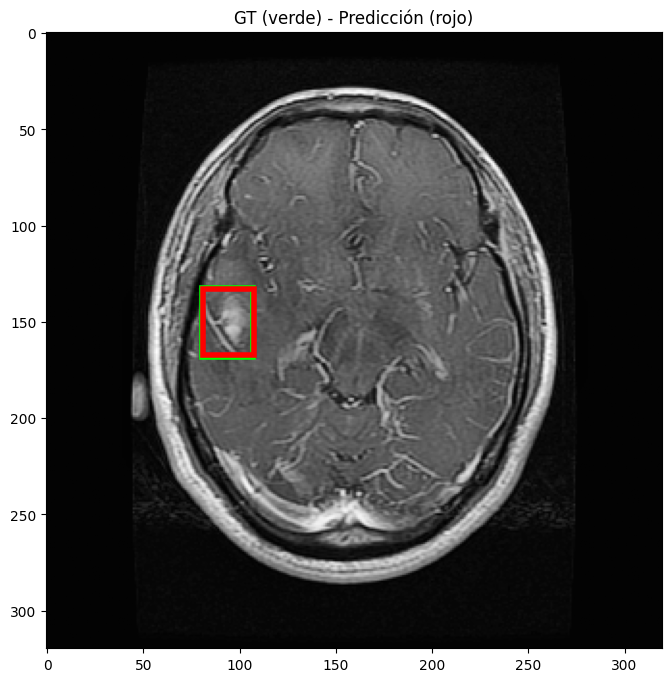

In [163]:
img = image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(img, cmap="gray")

print("GT boxes:")
for box in target["boxes"]:
    print(box)

    xmin, ymin, xmax, ymax = box.cpu().numpy()

    rect = plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="lime",
        linewidth=4
    )

    ax.add_patch(rect)

print("\nPredicciones:")
for box, score in zip(prediction["boxes"], prediction["scores"]):

    print(score.item(), box.cpu().numpy())

    xmin, ymin, xmax, ymax = box.cpu().numpy()

    rect = plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="red",
        linewidth=4
    )

    ax.add_patch(rect)

plt.title("GT (verde) - Predicción (rojo)")
plt.show()

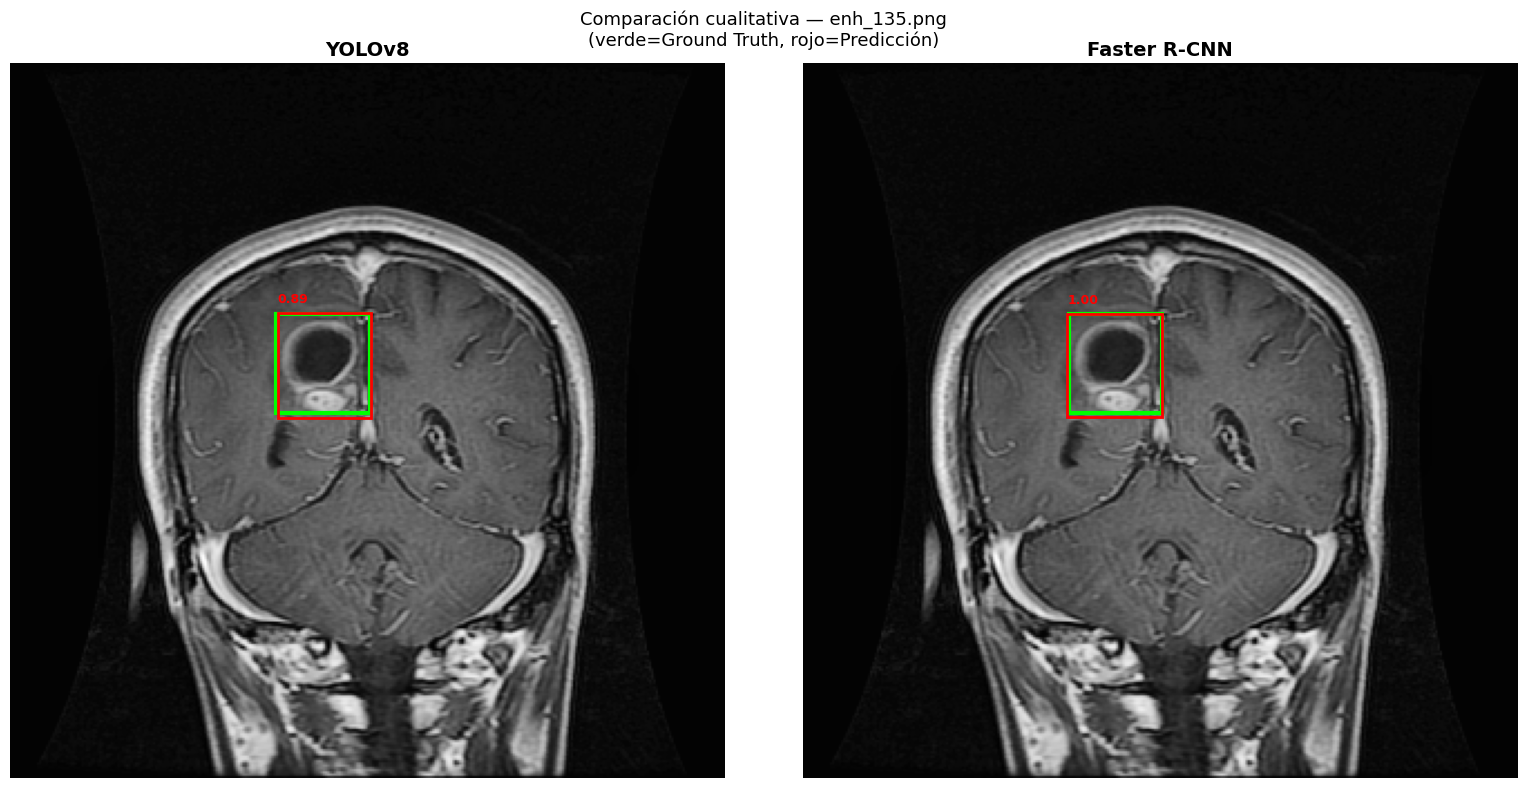

In [164]:
idx = random.randint(0, len(test_dataset) - 1)
image, target = test_dataset[idx]
img_name = test_dataset.images[idx]
img_full_path = os.path.join("./data/images/test", img_name)

yolo_pred = yolo_model.predict(img_full_path, conf=0.25, verbose=False)[0]

frcnn_model = model  # el "model" actual ya es Faster R-CNN
frcnn_model.eval()
with torch.no_grad():
    frcnn_pred = frcnn_model([image.to(device)])[0]

img_np = cv2.imread(img_full_path)
img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, title in zip(axes, ["YOLOv8", "Faster R-CNN"]):
    ax.imshow(img_np)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.axis("off")
    for box in target["boxes"]:
        xmin, ymin, xmax, ymax = box.numpy()
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                              fill=False, edgecolor="lime", linewidth=3)
        ax.add_patch(rect)

for box, score in zip(yolo_pred.boxes.xyxy.cpu(), yolo_pred.boxes.conf.cpu()):
    xmin, ymin, xmax, ymax = box.numpy()
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                          fill=False, edgecolor="red", linewidth=2)
    axes[0].add_patch(rect)
    axes[0].text(xmin, ymin - 5, f"{score:.2f}", color="red", fontsize=9, weight="bold")

for box, score in zip(frcnn_pred["boxes"], frcnn_pred["scores"]):
    if score < 0.30:
        continue
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                          fill=False, edgecolor="red", linewidth=2)
    axes[1].add_patch(rect)
    axes[1].text(xmin, ymin - 5, f"{score:.2f}", color="red", fontsize=9, weight="bold")

fig.suptitle(f"Comparación cualitativa — {img_name}\n(verde=Ground Truth, rojo=Predicción)", fontsize=13)
plt.tight_layout()
plt.savefig("comparacion_yolo_vs_frcnn.png", dpi=150, bbox_inches="tight")
plt.show()

In [165]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)
print(metrics.box.mp)
print(metrics.box.mr)

0.7484449357387806
0.9667008344093722
0.8659887389296493
0.9524828086084112
0.9006676249924968


# Tabla comparativa

---



In [166]:
import pandas as pd
import numpy as np

comparison = pd.DataFrame({

    "Modelo":[
        "YOLOv8",
        "Faster R-CNN"
    ],

    "mAP@50":[
        yolo_map50,
        float(results["map_50"])
    ],

    "Precision": [
        yolo_precision,
        precision
    ],

    "mAP@50-95":[
        yolo_map5095,
        float(results["map"])
    ],

    "Recall":[
        yolo_recall,
        recall
    ],

    "F1-Score": [
        yolo_f1,
        f1
    ],

    "Mean IoU":[
        yolo_metrics.get('mean_iou', 0),
        np.mean(ious)
    ],

    "Training Time (s)":[
        yolo_training_time,
        faster_training_time
    ],

    "Inference Time (s)":[
        yolo_inference_time,
        faster_inference_time
    ]
})

comparison

,Modelo,mAP@50,Precision,mAP@50-95,Recall,F1-Score,Mean IoU,Training Time (s),Inference Time (s)
0,YOLOv8,0.966701,0.952483,0.748445,0.900668,0.925850,0.807326,2013.183038,0.012502
1,Faster R-CNN,0.923619,0.899543,0.726063,0.927059,0.913093,0.771723,4362.890493,0.101473


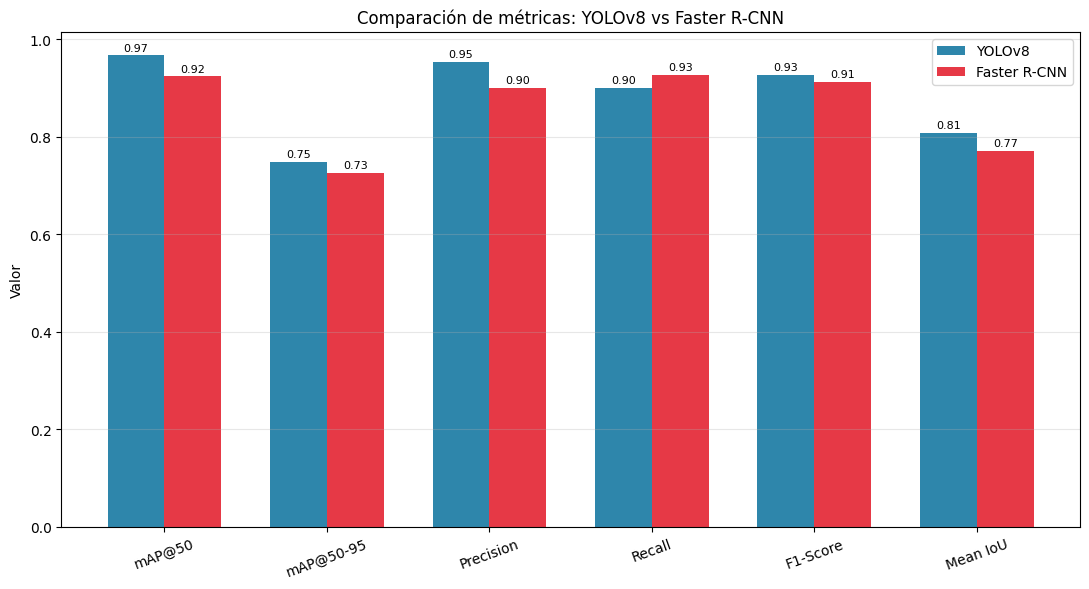

In [167]:
metricas_plot = ["mAP@50", "mAP@50-95", "Precision", "Recall", "F1-Score", "Mean IoU"]
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metricas_plot))
width = 0.35

yolo_vals  = [comparison.loc[0, m] for m in metricas_plot]
frcnn_vals = [comparison.loc[1, m] for m in metricas_plot]

ax.bar(x - width/2, yolo_vals, width, label="YOLOv8", color="#2E86AB")
ax.bar(x + width/2, frcnn_vals, width, label="Faster R-CNN", color="#E63946")
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, rotation=20)
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas: YOLOv8 vs Faster R-CNN")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (y, f) in enumerate(zip(yolo_vals, frcnn_vals)):
    ax.text(i - width/2, y + 0.01, f"{y:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, f + 0.01, f"{f:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("comparacion_metricas_barras.png", dpi=150, bbox_inches="tight")
plt.show()

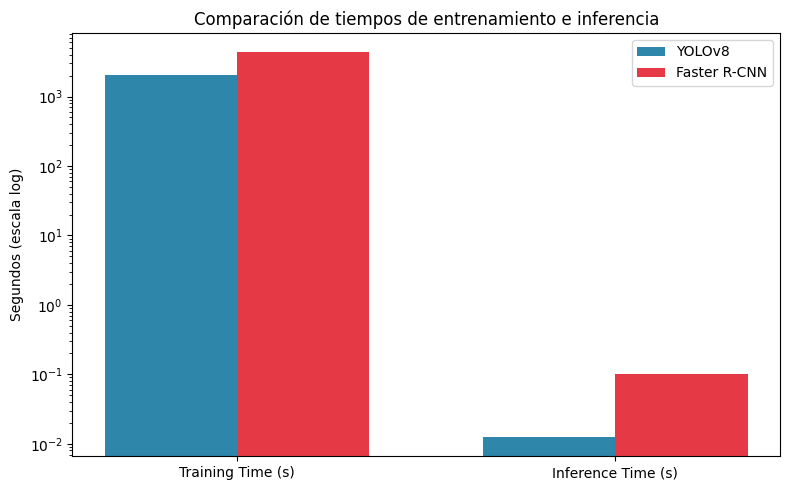

In [168]:
fig, ax = plt.subplots(figsize=(8, 5))
tiempos = ["Training Time (s)", "Inference Time (s)"]
x = np.arange(len(tiempos))
yolo_t  = [comparison.loc[0, t] for t in tiempos]
frcnn_t = [comparison.loc[1, t] for t in tiempos]

ax.bar(x - width/2, yolo_t, width, label="YOLOv8", color="#2E86AB")
ax.bar(x + width/2, frcnn_t, width, label="Faster R-CNN", color="#E63946")
ax.set_xticks(x)
ax.set_xticklabels(tiempos)
ax.set_yscale("log")
ax.set_ylabel("Segundos (escala log)")
ax.set_title("Comparación de tiempos de entrenamiento e inferencia")
ax.legend()
plt.tight_layout()
plt.savefig("comparacion_tiempos.png", dpi=150, bbox_inches="tight")
plt.show()